# Colab 6 — Mini AxiomCart End to End

**Goal:** Combine the core ideas:
- orchestrator
- product and support specialists
- fan-out
- synthesizer
- interrupt/resume

No LLM or API key is required.


In [1]:
!pip -q install -U langgraph


In [2]:
import re
from operator import add
from typing import Annotated

from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.types import Send, interrupt, Command
from langgraph.checkpoint.memory import InMemorySaver

class State(TypedDict):
    request: str
    results: Annotated[list[str], add]
    final_answer: str

ORDERS = {"ORD102": "Shipped — arrives tomorrow"}

def route(state: State): #conditional_edge => routing => parallelization
    q = state["request"].lower()
    sends = []
    if any(x in q for x in ["headphone", "sony", "product", "alternative"]):
        sends.append(Send("product_agent", {"request": state["request"], "results": []}))
    if any(x in q for x in ["order", "late", "delivery", "refund"]):
        sends.append(Send("support_agent", {"request": state["request"], "results": []}))
    return sends

def product_agent(state: State):
    return {"results": ["Product specialist: Sony WH-1000XM5 — $299."]}

def support_agent(state: State):
    match = re.search(r"ORD\d+", state["request"], re.I)
    order_id = match.group(0).upper() if match else interrupt({
        "question": "Please provide your order ID.",
        "example": "ORD102"
    })
    return {"results": [f"Support specialist: {order_id} — {ORDERS.get(order_id, 'not found')}."]}

def synthesizer(state: State):
    return {"final_answer": " ".join(state["results"])}

builder = StateGraph(State)
builder.add_node("product_agent", product_agent)
builder.add_node("support_agent", support_agent)
builder.add_node("synthesizer", synthesizer)

builder.add_conditional_edges(START, route, ["product_agent", "support_agent"])
builder.add_edge("product_agent", "synthesizer")
builder.add_edge("support_agent", "synthesizer")
builder.add_edge("synthesizer", END)

graph = builder.compile(checkpointer=InMemorySaver())
config = {"configurable": {"thread_id": "axiomcart-demo"}}

first = graph.invoke({
    "request": "My order is late. Show me Sony alternatives too.",
    "results": [],
    "final_answer": ""
}, config=config)

first


{'request': 'My order is late. Show me Sony alternatives too.',
 'results': ['Product specialist: Sony WH-1000XM5 — $299.'],
 'final_answer': '',
 '__interrupt__': [Interrupt(value={'question': 'Please provide your order ID.', 'example': 'ORD102'}, id='312d63d47508e5cf6745bdf1bcb767e5')]}

In [5]:
# Supply the missing order ID and resume.
order_id = "ORD102"
final = graph.invoke(Command(resume=order_id), config=config)
final

{'request': 'My order is late. Show me Sony alternatives too.',
 'results': ['Product specialist: Sony WH-1000XM5 — $299.',
  'Support specialist: ORD102 — Shipped — arrives tomorrow.'],
 'final_answer': 'Product specialist: Sony WH-1000XM5 — $299. Support specialist: ORD102 — Shipped — arrives tomorrow.'}

In [6]:
print(order_id)

ORD102


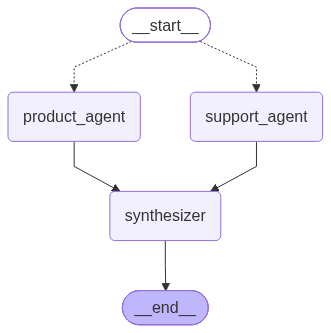

In [7]:
from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

### Transition to the GitHub repo

> “The production repository adds real tools, model routing, streaming, voice, typed context, and API boundaries—but its core architecture is this notebook.”
